# ML Basket 2: Expanding Beta Classification (High vs Low Beta)

## Overview
This Jupyter Notebook constructs ML-ready portfolios by classifying factors into HIGH_BETA (offensive) and LOW_BETA (defensive) categories using expanding window CAPM beta estimates. It dynamically selects top/bottom 50% of factors by beta, computes equal-weighted returns and turnovers, and generates aggregated baskets for machine learning applications.

## Key Features
- **Beta Estimation**: Expanding window CAPM betas (minimum 60 months) for 25 factors.
- **Dynamic Selection**: Monthly rebalancing based on lagged betas (no lookahead bias).
- **Portfolio Construction**: Equal-weighted aggregation of HIGH_BETA and LOW_BETA portfolios.
- **Turnover Calculation**: Dynamic turnover metrics for transaction cost analysis.
- **Visualization**: Cumulative returns plots, correlation heatmaps (signals and returns).

## Methodology
1. Load factor excess returns, compute expanding betas using CAPM.
2. Rank factors by lagged beta, select top/bottom 50% for HIGH_BETA/LOW_BETA.
3. Aggregate into dynamic portfolios (EW gross returns).
4. Compute turnovers and allocations.
5. Save baskets, allocations, betas; generate heatmaps and plots.

## Dependencies
- Libraries: pandas, numpy, matplotlib, seaborn, scipy, pathlib.
- Data: Signal Parquet files, NYSE P20 benchmark, FF5 factors.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Adjust FEATURES_BASELINE if needed.
2. Run cells to load data, compute betas, construct portfolios, and save outputs.
3. Review saved Parquet files, heatmaps, and cumulative returns plots.

## Output Files
- **data/ml_data/baskets/basket_2_beta_expansion.parquet**: Parquet with Market, HIGH_BETA, LOW_BETA returns, and aggregated turnovers.
- **data/ml_data/baskets/allocations/basket_2_allocations.parquet**: Parquet with monthly allocations for HIGH_BETA and LOW_BETA.
- **data/ml_data/features/baseline/basket_2_betas.parquet**: Parquet with expanding beta estimates for all factors.
- **results/figures/appendix/s02_appendix_A3_signal_correlations.png**: Heatmap of cross-sectional signal correlations.
- **results/figures/appendix/s02_appendix_A4_return_correlations.png**: Heatmap of time-series return correlations.

This notebook prepares beta-based baskets for ML modeling, ensuring dynamic factor selection and academic rigor.

In [20]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 : IMPORTS & GLOBAL CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistical models
from scipy import stats
from scipy.stats import zscore

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 4)

print("="*100)
print("📦 NOTEBOOK 2 : BETA EXPANSION STRATEGY")
print("="*100)
print("\n✅ Imports loaded successfully")
print("="*100)

📦 NOTEBOOK 2 : BETA EXPANSION STRATEGY

✅ Imports loaded successfully


In [21]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 : FACTOR UNIVERSE CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🎯 CONFIGURATION : FACTOR UNIVERSE (BASELINE THÉORIQUE)")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# FEATURES_BASELINE : Sélection théorique des legs (P10 ou P1)
# ════════════════════════════════════════════════════════════════════════════
# 
# PRINCIPE :
#   • P10 = "High is Good"  → Acheter les 10% meilleurs
#   • P1  = "Low is Good"   → Acheter les 10% pires (inversé)
#
# JUSTIFICATION :
#   Basé sur la littérature académique (Fama-French, Novy-Marx, etc.)
#   Chaque facteur est sélectionné dans sa direction théoriquement optimale
# ════════════════════════════════════════════════════════════════════════════

FEATURES_BASELINE = {
    # ────────────────────────────────────────────────────────────────────────
    # 1. PROFITABILITY (5 factors) - Theory: Novy-Marx (2013), Fama-French
    # ────────────────────────────────────────────────────────────────────────
    'gross_profitability': 'P10',       # High GP/AT = Strong pricing power (Novy-Marx 2013)
    'operating_profitability': 'P10',   # High OP/AT = Quality (Fama-French 2015)
    'return_on_assets': 'P10',          # High ROA = Profitability (DuPont analysis)
    'change_asset_turnover': 'P10',     # Improving turnover = Efficiency gains
    'change_profit_margin': 'P10',      # Improving margin = Competitive advantage
    
    # ────────────────────────────────────────────────────────────────────────
    # 2. INVESTMENT (6 factors) - Theory: Cooper et al. (2008), Titman et al.
    # ────────────────────────────────────────────────────────────────────────
    'roic': 'P10',                      # HIGH ROIC = Capital efficiency (Brown & Rowe 2007)
    'asset_growth': 'P1',               # LOW asset growth = No empire building (Cooper 2008)
    'investment_capex': 'P1',           # LOW CapEx = Conservative (Titman 2004)
    'capex_inventory_growth': 'P1',     # LOW combined growth = Quality
    'net_share_issues': 'P1',           # LOW dilution = Shareholder-friendly (Pontiff 2008)
    'capex_growth': 'P1',               # LOW CapEx growth = Sustainable
    'sales_growth': 'P1',               # LOW sales growth = Avoid over-expansion (Lakonishok)
    
    # ────────────────────────────────────────────────────────────────────────
    # 3. ACCRUALS & QUALITY (4 factors) - Theory: Sloan (1996), Richardson
    # ────────────────────────────────────────────────────────────────────────
    'working_capital_accruals': 'P1',   # LOW accruals = High earnings quality (Sloan 1996)
    'sales_receivables_gap': 'P10',     # HIGH gap = Real demand (vs channel stuffing)
    'receivables_turnover': 'P10',      # HIGH turnover = Fast collection (credit quality)
    'operating_leverage': 'P10',        # HIGH sales-inventory gap = Real growth
    
    # ────────────────────────────────────────────────────────────────────────
    # 4. LIQUIDITY & SOLVENCY (5 factors) - Theory: Altman Z-score, Piotroski
    # ────────────────────────────────────────────────────────────────────────
    'cash_cushion': 'P10',              # HIGH cash/assets = Financial flexibility
    'debt_capacity': 'P10',             # HIGH debt capacity = Strong tangible base (Almeida 2007)
    'book_leverage': 'P1',              # LOW leverage = Safety (Bhandari 1988 reversal)
    'change_current_ratio': 'P10',      # Improving liquidity = Reduced distress risk
    
    # ────────────────────────────────────────────────────────────────────────
    # 5. OPERATING EFFICIENCY (5 factors) - Theory: Asset pricing, Efficiency
    # ────────────────────────────────────────────────────────────────────────
    'asset_turnover': 'P10',            # HIGH asset turnover = Revenue generation efficiency
    'cash_productivity': 'P10',         # HIGH sales/cash = Efficient cash deployment
    'depreciation_to_ppe': 'P1',        # LOW depreciation = Younger assets (less wear)
    'change_depreciation': 'P1',        # LOW Δ depreciation = Stable asset base
    'tax_income_ratio': 'P10',          # HIGH tax efficiency = Retention quality
}


# ════════════════════════════════════════════════════════════════════════════
# VALIDATION
# ════════════════════════════════════════════════════════════════════════════

print(f"\n✅ Factor universe defined :")
print(f"   • Total factors   : {len(FEATURES_BASELINE)}")
print(f"   • P10 factors     : {sum(1 for v in FEATURES_BASELINE.values() if v == 'P10')}")
print(f"   • P1 factors      : {sum(1 for v in FEATURES_BASELINE.values() if v == 'P1')}")

print(f"\n📊 Factor breakdown by category :")
categories = {
    'Profitability': ['gross_profitability', 'operating_profitability', 'return_on_assets', 
                      'change_asset_turnover', 'change_profit_margin'],
    'Investment': ['noa_change', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
                   'inventory_change', 'net_share_issues', 'capex_growth', 'sales_growth'],
    'Accruals & Quality': ['working_capital_accruals', 'sales_receivables_gap', 
                           'receivables_turnover', 'operating_leverage'],
    'Liquidity & Solvency': ['cash_cushion', 'book_leverage', 'change_current_ratio', 
                             'change_quick_ratio'],
    'Operating Efficiency': ['cash_productivity', 'depreciation_to_ppe', 
                             'change_depreciation', 'tax_income_ratio']
}


for cat, factors in categories.items():
    print(f"   • {cat:<25} : {len(factors)} factors")

print("\n" + "="*100)

🎯 CONFIGURATION : FACTOR UNIVERSE (BASELINE THÉORIQUE)

✅ Factor universe defined :
   • Total factors   : 25
   • P10 factors     : 15
   • P1 factors      : 10

📊 Factor breakdown by category :
   • Profitability             : 5 factors
   • Investment                : 8 factors
   • Accruals & Quality        : 4 factors
   • Liquidity & Solvency      : 4 factors
   • Operating Efficiency      : 4 factors



In [22]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 : DATA LOADING
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📦 CHARGEMENT DES DONNÉES FACTEURS")
print("="*100)

def load_factor_returns(features_config: Dict[str, str], 
                       data_dir: Path = Path('data/portfolios')) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load factor returns and compute excess returns for CAPM beta estimation.
    
    Returns:
    --------
    df_returns : pd.DataFrame
        Factor EXCESS returns (R - RF) + Market excess return
    df_turnover : pd.DataFrame
        Factor turnover (unchanged)
    """
    
    returns_dict = {}
    turnover_dict = {}
    
    # ════════════════════════════════════════════════════════════════════════
    # STEP 1 : CHARGER NYSE P20 BENCHMARK
    # ════════════════════════════════════════════════════════════════════════
    
    nyse_p20_path = Path('data/ml_data/market/market_returns_ew_nys80.parquet')
    
    if not nyse_p20_path.exists():
        print(f"⚠️  NYSE P20 benchmark not found. Please run 06_1 first.")
        print(f"   Expected path: {nyse_p20_path}")
        raise FileNotFoundError(f"Missing {nyse_p20_path}")
    
    df_nyse_p20 = pd.read_parquet(nyse_p20_path)
    df_nyse_p20['date'] = pd.to_datetime(df_nyse_p20['date'])
    df_nyse_p20 = df_nyse_p20.set_index('date')
    
    market_ret_gross = df_nyse_p20['ret_market_ew'].copy()
    
    print(f"\n✅ Loaded NYSE P20 EW benchmark : {len(market_ret_gross)} months")
    print(f"   Mean return : {market_ret_gross.mean()*100:.2f}% per month ({market_ret_gross.mean()*12*100:.2f}% ann.)")
    
    # ════════════════════════════════════════════════════════════════════════
    # STEP 2 : CHARGER RF (Fama-French)
    # ════════════════════════════════════════════════════════════════════════
    
    ff_path = Path('data/factors/ff/FF5.csv')
    df_ff = pd.read_csv(ff_path)
    df_ff['dateff'] = pd.to_datetime(df_ff['dateff'])
    df_ff = df_ff.set_index('dateff')
    
    rf = df_ff['rf']
    
    print(f"✅ Loaded RF : {len(rf)} months")
    print(f"   Mean RF : {rf.mean()*100:.2f}% per month")
    
    # ════════════════════════════════════════════════════════════════════════
    # STEP 3 : CHARGER FACTOR RETURNS (BRUT) ET CALCULER EXCESS
    # ════════════════════════════════════════════════════════════════════════
    
    print(f"\n🔄 Loading {len(features_config)} factors...")
    
    for factor, leg in features_config.items():
        signal_path = data_dir / f'{factor}_signal.parquet'
        
        if not signal_path.exists():
            print(f"⚠️  File not found : {signal_path.name}")
            continue
        
        signal_df = pd.read_parquet(signal_path)
        signal_df['date'] = pd.to_datetime(signal_df['date'])
        signal_df = signal_df.set_index('date')
        
        if leg == 'P10':
            factor_ret_gross = signal_df['ret_high_ew']
            turnover_dict[f'{factor}_turnover'] = signal_df['turnover_high_ew']
        else:
            factor_ret_gross = signal_df['ret_low_ew']
            turnover_dict[f'{factor}_turnover'] = signal_df['turnover_low_ew']
        
        # EXCESS RETURN : R_factor - RF
        common_dates = factor_ret_gross.index.intersection(rf.index)
        factor_ret_excess = factor_ret_gross.loc[common_dates] - rf.loc[common_dates]
        
        returns_dict[factor] = factor_ret_excess
    
    # ════════════════════════════════════════════════════════════════════════
    # STEP 4 : CONSTRUIRE DATAFRAME AVEC MARKET EXCESS RETURN
    # ════════════════════════════════════════════════════════════════════════
    
    df_returns = pd.DataFrame(returns_dict)
    df_turnover = pd.DataFrame(turnover_dict)
    
    # MARKET EXCESS RETURN : R_market - RF
    common_dates_mkt = market_ret_gross.index.intersection(rf.index)
    market_ret_excess = market_ret_gross.loc[common_dates_mkt] - rf.loc[common_dates_mkt]
    market_ret_excess = market_ret_excess.reindex(df_returns.index)
    
    df_returns.insert(0, 'Market', market_ret_excess)
    
    print(f"\n✅ Factor returns loaded (EXCESS) :")
    print(f"   • Shape : {df_returns.shape}")
    print(f"   • Period : {df_returns.index.min().date()} → {df_returns.index.max().date()}")
    
    return df_returns, df_turnover


# ════════════════════════════════════════════════════════════════════════════
# LOAD FACTOR RETURNS (EXCESS pour beta)
# ════════════════════════════════════════════════════════════════════════════

df_returns_EXCESS, df_turnover = load_factor_returns(FEATURES_BASELINE)

# ════════════════════════════════════════════════════════════════════════════
# LOAD FACTOR RETURNS (BRUT pour portfolios)
# ════════════════════════════════════════════════════════════════════════════

print(f"\n🔄 Loading GROSS returns for portfolio construction...")

returns_dict_GROSS = {}

for factor, leg in FEATURES_BASELINE.items():
    signal_path = Path(f'data/portfolios/{factor}_signal.parquet')
    
    if not signal_path.exists():
        continue
    
    signal_df = pd.read_parquet(signal_path)
    signal_df['date'] = pd.to_datetime(signal_df['date'])
    signal_df = signal_df.set_index('date')
    
    if leg == 'P10':
        returns_dict_GROSS[factor] = signal_df['ret_high_ew']
    else:
        returns_dict_GROSS[factor] = signal_df['ret_low_ew']

df_returns_GROSS = pd.DataFrame(returns_dict_GROSS)

print(f"✅ GROSS returns loaded : {df_returns_GROSS.shape}")
print("="*100)


📦 CHARGEMENT DES DONNÉES FACTEURS

✅ Loaded NYSE P20 EW benchmark : 732 months
   Mean return : 1.15% per month (13.77% ann.)
✅ Loaded RF : 738 months
   Mean RF : 0.36% per month

🔄 Loading 25 factors...

✅ Factor returns loaded (EXCESS) :
   • Shape : (738, 26)
   • Period : 1963-07-31 → 2024-12-31

🔄 Loading GROSS returns for portfolio construction...
✅ GROSS returns loaded : (738, 25)


GENERATING CORRELATION HEATMAPS (SEPARATED)

📊 Loading signal data...

📊 Loading portfolio returns...
✓ Matrices loaded: (25, 25) & (25, 25)

FIGURE A3: SIGNAL CORRELATIONS

✅ FIGURE A3 SAVED: results/figures/appendix/s02_appendix_A3_signal_correlations.png


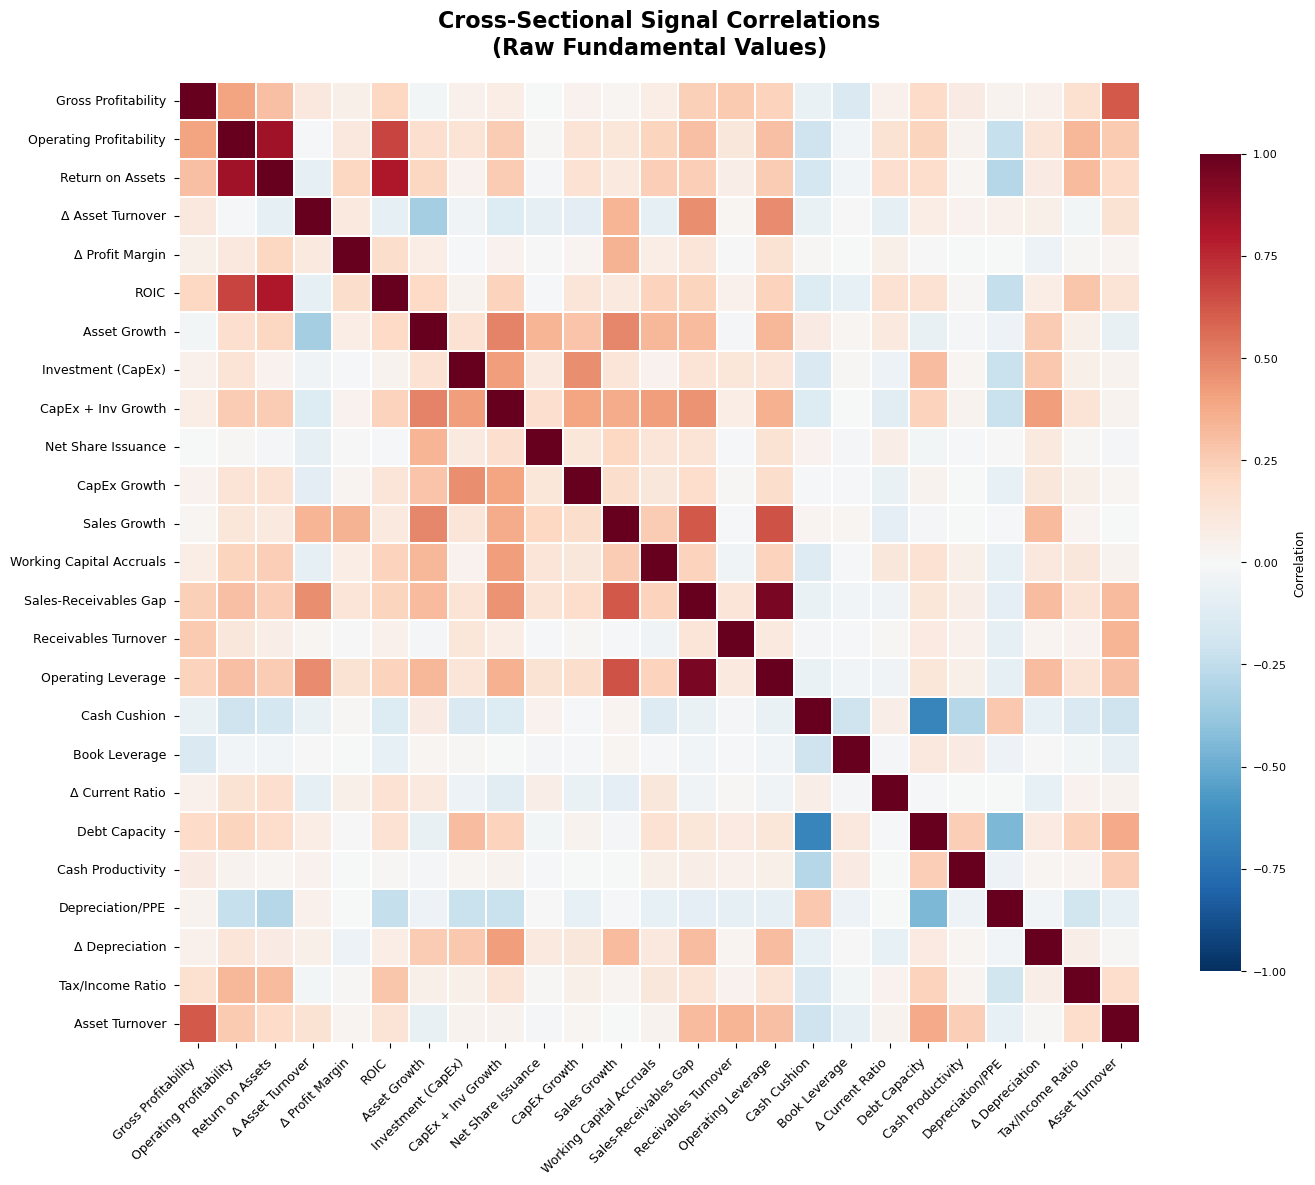


FIGURE A4: RETURN CORRELATIONS

✅ FIGURE A4 SAVED: results/figures/appendix/s02_appendix_A4_return_correlations.png


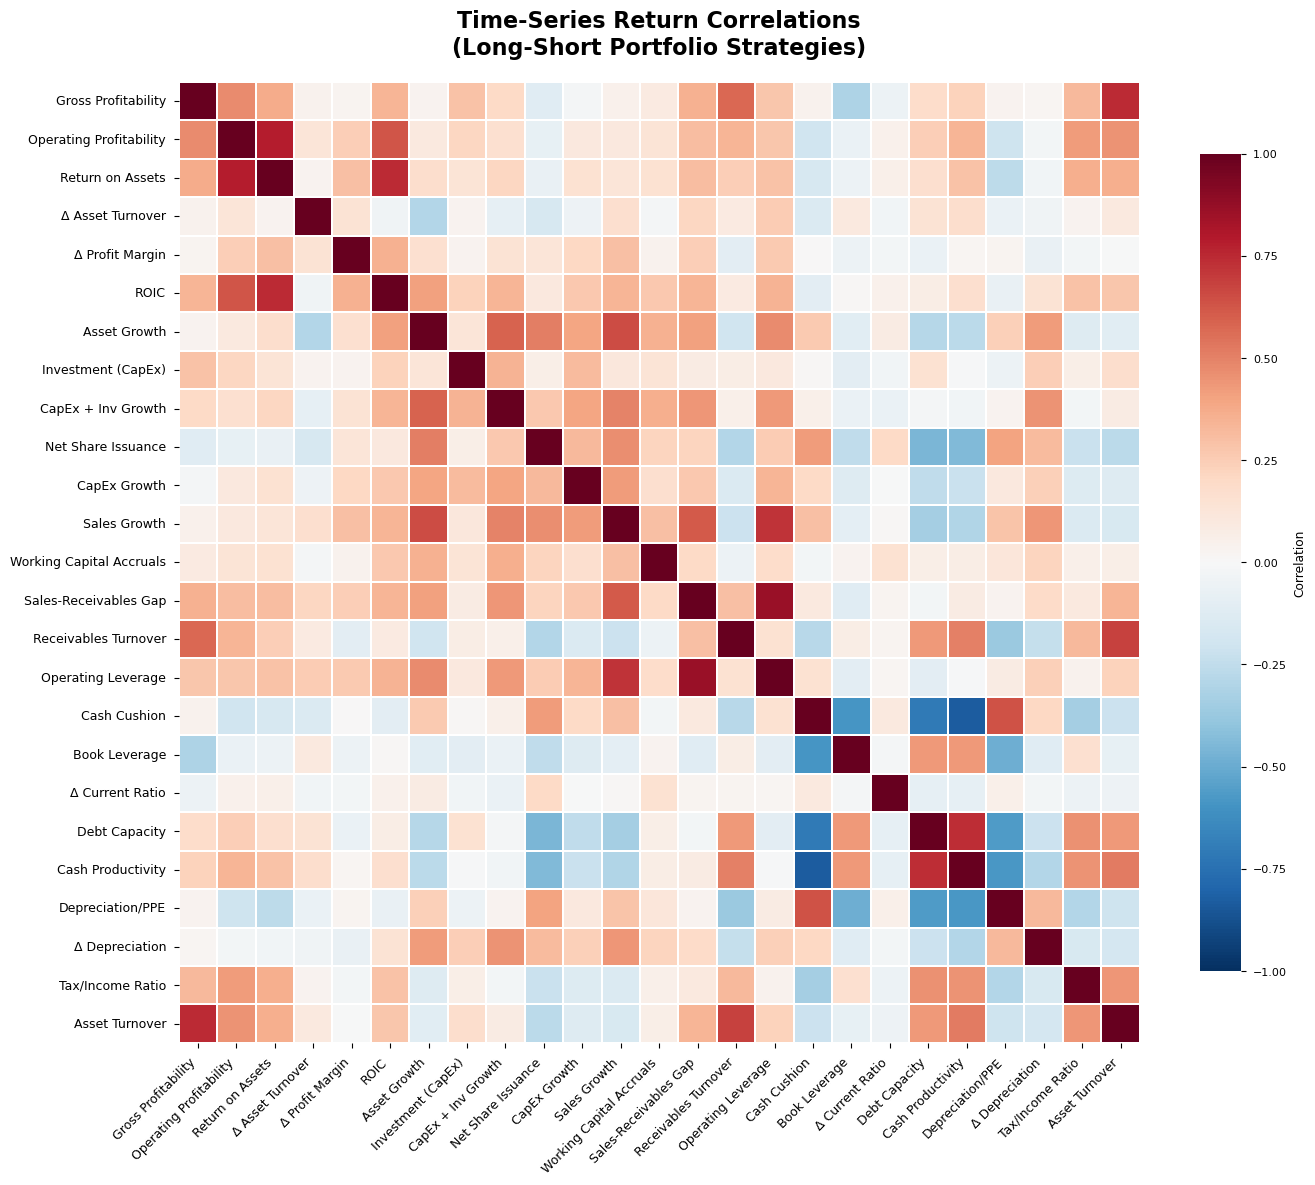

In [23]:
"""
════════════════════════════════════════════════════════════════════════════════
FIGURE A3 & A4: CORRELATION HEATMAPS (SEPARATED)
════════════════════════════════════════════════════════════════════════════════
Panel A: Signal Correlations (Raw Values)
Panel B: Return Correlations (Long-Short Strategies)
"""

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

SIGNALS_FILE = Path('data/signals/signals_ALL.parquet')
PORTFOLIOS_DIR = Path('data/portfolios')
OUTPUT_DIR = Path('results/figures/appendix')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SIGNALS = [
    'gross_profitability', 'operating_profitability', 'return_on_assets',
    'change_asset_turnover', 'change_profit_margin',
    'roic', 'asset_growth', 'investment_capex', 'capex_inventory_growth',
    'net_share_issues', 'capex_growth',
    'sales_growth', 'working_capital_accruals', 'sales_receivables_gap',
    'receivables_turnover',
    'operating_leverage', 'cash_cushion', 'book_leverage',
    'change_current_ratio', 'debt_capacity',
    'cash_productivity', 'depreciation_to_ppe', 'change_depreciation',
    'tax_income_ratio', 'asset_turnover'
]

# ✅ NOMS COMPLETS (pour lisibilité)
SIGNAL_NAMES_FULL = {
    'gross_profitability': 'Gross Profitability',
    'operating_profitability': 'Operating Profitability',
    'return_on_assets': 'Return on Assets',
    'change_asset_turnover': 'Δ Asset Turnover',
    'change_profit_margin': 'Δ Profit Margin',
    'roic': 'ROIC',
    'asset_growth': 'Asset Growth',
    'investment_capex': 'Investment (CapEx)',
    'capex_inventory_growth': 'CapEx + Inv Growth',
    'net_share_issues': 'Net Share Issuance',
    'capex_growth': 'CapEx Growth',
    'sales_growth': 'Sales Growth',
    'working_capital_accruals': 'Working Capital Accruals',
    'sales_receivables_gap': 'Sales-Receivables Gap',
    'receivables_turnover': 'Receivables Turnover',
    'operating_leverage': 'Operating Leverage',
    'cash_cushion': 'Cash Cushion',
    'book_leverage': 'Book Leverage',
    'change_current_ratio': 'Δ Current Ratio',
    'debt_capacity': 'Debt Capacity',
    'cash_productivity': 'Cash Productivity',
    'depreciation_to_ppe': 'Depreciation/PPE',
    'change_depreciation': 'Δ Depreciation',
    'tax_income_ratio': 'Tax/Income Ratio',
    'asset_turnover': 'Asset Turnover'
}

print("="*80)
print("GENERATING CORRELATION HEATMAPS (SEPARATED)")
print("="*80)

# ════════════════════════════════════════════════════════════════════════════
# LOAD DATA (Une seule fois)
# ════════════════════════════════════════════════════════════════════════════

print("\n📊 Loading signal data...")
df_signals = pd.read_parquet(SIGNALS_FILE)
# Filter to study period (July 1963 - June 2024)
df_signals.index = pd.to_datetime(df_signals.index)
df_signals = df_signals[(df_signals.index >= '1963-07-31') & (df_signals.index <= '2024-06-28')]

signal_data = df_signals[SIGNALS].copy()
signal_data.columns = [SIGNAL_NAMES_FULL[col] for col in signal_data.columns]
corr_signals = signal_data.corr(method='pearson')

print("\n📊 Loading portfolio returns...")
returns_dict = {}
for signal in SIGNALS:
    portfolio_file = PORTFOLIOS_DIR / f'{signal}_signal.parquet'
    if portfolio_file.exists():
        df_port = pd.read_parquet(portfolio_file)
        returns_dict[SIGNAL_NAMES_FULL[signal]] = df_port.set_index('date')['ret_ls_ew']

df_returns = pd.DataFrame(returns_dict)
corr_returns = df_returns.corr(method='pearson')

print(f"✓ Matrices loaded: {corr_signals.shape} & {corr_returns.shape}\n")

# ════════════════════════════════════════════════════════════════════════════
# FIGURE A3: SIGNAL CORRELATIONS
# ════════════════════════════════════════════════════════════════════════════

print("="*80)
print("FIGURE A3: SIGNAL CORRELATIONS")
print("="*80)

plt.style.use('seaborn-v0_8-paper')
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_signals, 
    cmap='RdBu_r', 
    center=0, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.3,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot=False,
    ax=ax
)

ax.set_title(
    'Cross-Sectional Signal Correlations\n(Raw Fundamental Values)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=9, rotation=45)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

output_a3 = OUTPUT_DIR / 's02_appendix_A3_signal_correlations.png'
plt.savefig(output_a3, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✅ FIGURE A3 SAVED: {output_a3}")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE A4: RETURN CORRELATIONS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FIGURE A4: RETURN CORRELATIONS")
print("="*80)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_returns, 
    cmap='RdBu_r', 
    center=0, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.3,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot=False,
    ax=ax
)

ax.set_title(
    'Time-Series Return Correlations\n(Long-Short Portfolio Strategies)', 
    fontsize=16, 
    fontweight='bold',
    pad=20
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=9, rotation=45)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

output_a4 = OUTPUT_DIR / 's02_appendix_A4_return_correlations.png'
plt.savefig(output_a4, dpi=300, bbox_inches='tight', facecolor='white')

print(f"\n✅ FIGURE A4 SAVED: {output_a4}")
print("="*80)
plt.show()

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 : ROLLING BETA ESTIMATION (CAPM)
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 CALCUL DES ROLLING BETAS (EXPANDING WINDOW)")
print("="*100)

def compute_expanding_beta(factor_returns: pd.Series, 
                          market_returns: pd.Series,
                          min_periods: int = 36) -> pd.Series:
    """
    Compute expanding window CAPM beta.
    
    Parameters:
    -----------
    factor_returns : pd.Series
        Factor excess returns
    market_returns : pd.Series
        Market excess returns
    min_periods : int
        Minimum number of observations to start computing beta
    
    Returns:
    --------
    beta_series : pd.Series
        Rolling beta estimates
    
    Methodology:
    ------------
    β_t = Cov(R_factor, R_market)_[0:t] / Var(R_market)_[0:t]
    
    Uses EXPANDING window (not rolling) to utilize all available history.
    """
    
    # Align series
    merged = pd.concat([factor_returns, market_returns], axis=1).dropna()
    merged.columns = ['factor', 'market']
    
    # Compute expanding covariance and variance
    expanding_cov = merged['factor'].expanding(min_periods=min_periods).cov(merged['market'])
    expanding_var = merged['market'].expanding(min_periods=min_periods).var()
    
    # Beta = Cov / Var
    beta_series = expanding_cov / expanding_var
    
    return beta_series


def compute_all_betas(df_returns: pd.DataFrame, 
                     min_periods: int = 36) -> pd.DataFrame:
    """
    Compute expanding betas for all factors.
    
    Parameters:
    -----------
    df_returns : pd.DataFrame
        Returns DataFrame (first column = Market)
    min_periods : int
        Minimum observations for beta estimation
    
    Returns:
    --------
    df_betas : pd.DataFrame
        Beta estimates for all factors
    """
    
    market_ret = df_returns['Market']
    factor_names = [col for col in df_returns.columns if col != 'Market']
    
    betas_dict = {}
    
    print(f"\n🔄 Computing betas for {len(factor_names)} factors...")
    print(f"   • Min periods : {min_periods} months")
    print(f"   • Window type : EXPANDING (uses all historical data)")
    
    for factor in factor_names:
        beta = compute_expanding_beta(df_returns[factor], market_ret, min_periods)
        betas_dict[factor] = beta
    
    df_betas = pd.DataFrame(betas_dict)
    
    return df_betas


# ════════════════════════════════════════════════════════════════════════════
# COMPUTE BETAS
# ════════════════════════════════════════════════════════════════════════════

MIN_PERIODS = 60  # 3 years minimum

# CELL 4 - Ligne qui appelle compute_all_betas :
df_betas = compute_all_betas(df_returns_EXCESS, min_periods=MIN_PERIODS)  # ✅ EXCESS pour beta


print(f"\n✅ Betas computed :")
print(f"   • Shape           : {df_betas.shape}")
print(f"   • Valid from      : {df_betas.dropna(how='all').index.min().date()}")
print(f"   • Missing values  : {df_betas.isnull().sum().sum()}")

print(f"\n📊 Beta statistics (latest values) :")
latest_betas = df_betas.iloc[-1].dropna().sort_values()
print(f"\n   🔽 Lowest Betas (Defensive) :")
print(latest_betas.head(10).to_string())

print(f"\n   🔼 Highest Betas (Offensive) :")
print(latest_betas.tail(10).to_string())

print(f"\n📊 Beta range over time :")
print(df_betas.describe().round(4).to_string())

print("\n" + "="*100)

📈 CALCUL DES ROLLING BETAS (EXPANDING WINDOW)

🔄 Computing betas for 25 factors...
   • Min periods : 60 months
   • Window type : EXPANDING (uses all historical data)

✅ Betas computed :
   • Shape           : (732, 25)
   • Valid from      : 1968-06-28
   • Missing values  : 1487

📊 Beta statistics (latest values) :

   🔽 Lowest Betas (Defensive) :
depreciation_to_ppe        0.9242
cash_productivity          0.9527
net_share_issues           0.9534
asset_turnover             0.9741
debt_capacity              1.0241
gross_profitability        1.0413
receivables_turnover       1.0464
operating_profitability    1.0781
return_on_assets           1.0824
tax_income_ratio           1.0905

   🔼 Highest Betas (Offensive) :
asset_growth                1.1304
capex_growth                1.1311
working_capital_accruals    1.1424
sales_receivables_gap       1.1451
change_asset_turnover       1.1506
cash_cushion                1.1512
operating_leverage          1.1629
change_current_ratio        

In [25]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 : DYNAMIC PORTFOLIO CONSTRUCTION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🏗️  CONSTRUCTION DES PORTFOLIOS DYNAMIQUES (BETA-BASED)")
print("="*100)

def construct_beta_portfolios(df_returns_EXCESS: pd.DataFrame,
                              df_returns_GROSS: pd.DataFrame,
                              df_betas: pd.DataFrame,
                              top_pct: float = 0.5) -> Tuple[pd.Series, pd.Series, pd.DataFrame]:
    """
    Construct dynamic HIGH_BETA and LOW_BETA portfolios.
    
    Parameters:
    -----------
    df_returns_EXCESS : pd.DataFrame
        Factor EXCESS returns (NOT USED for portfolio returns, only for context)
    df_returns_GROSS : pd.DataFrame
        Factor GROSS returns (USED for portfolio returns)
    df_betas : pd.DataFrame
        Rolling beta estimates (computed from EXCESS returns)
    top_pct : float
        Percentage of factors in each basket (0.5 = top/bottom 50%)
    
    Returns:
    --------
    high_beta_ret : pd.Series
        HIGH_BETA portfolio returns (Equal-Weighted GROSS)
    low_beta_ret : pd.Series
        LOW_BETA portfolio returns (Equal-Weighted GROSS)
    allocations : pd.DataFrame
        Monthly allocations (1 = in basket, 0 = out)
    
    Methodology:
    ------------
    At each month t:
      1. Rank factors by beta_{t-1} (computed from EXCESS returns)
      2. Top X% highest beta → HIGH_BETA basket
      3. Top X% lowest beta  → LOW_BETA basket
      4. Compute Equal-Weighted returns using GROSS returns
    """
    
    n_factors = len(df_betas.columns)
    n_select = int(n_factors * top_pct)
    
    print(f"\n🎯 Portfolio construction parameters :")
    print(f"   • Total factors       : {n_factors}")
    print(f"   • Selection pct       : {top_pct*100:.0f}%")
    print(f"   • Factors per basket  : {n_select}")
    
    high_beta_returns = []
    low_beta_returns = []
    high_alloc_list = []
    low_alloc_list = []
    
    # ════════════════════════════════════════════════════════════════════════════
    # LAG BETAS BY 1 MONTH : Formation t-1, Holding t (NO LOOKAHEAD)
    # ════════════════════════════════════════════════════════════════════════════
    
    df_betas_lagged = df_betas.shift(1)
    dates = df_betas_lagged.dropna(how='all').index
    
    print(f"\n🔄 Constructing portfolios for {len(dates)} months...")
    print(f"   ⚠️  TIMING : Using beta_{{t-1}} (lagged) for formation, ret_t (GROSS) for holding")
    print(f"   • First valid date : {dates[0].date()} (beta from previous month)")
    
    for date in dates:
        # ────────────────────────────────────────────────────────────────────────
        # FORMATION (END OF MONTH t-1) : Get betas and rank factors
        # ────────────────────────────────────────────────────────────────────────
        betas_t_minus_1 = df_betas_lagged.loc[date].dropna()
        
        if len(betas_t_minus_1) < n_select * 2:
            high_beta_returns.append(np.nan)
            low_beta_returns.append(np.nan)
            high_alloc_list.append(pd.Series(0, index=df_betas.columns))
            low_alloc_list.append(pd.Series(0, index=df_betas.columns))
            continue
        
        betas_sorted = betas_t_minus_1.sort_values()
        
        # Select top/bottom
        low_beta_factors = betas_sorted.head(n_select).index.tolist()
        high_beta_factors = betas_sorted.tail(n_select).index.tolist()
        
        # ────────────────────────────────────────────────────────────────────────
        # HOLDING (MONTH t) : Realize GROSS returns
        # ────────────────────────────────────────────────────────────────────────
        
        # ✅ UTILISER GROSS RETURNS (pas excess!)
        if date not in df_returns_GROSS.index:
            high_beta_returns.append(np.nan)
            low_beta_returns.append(np.nan)
            high_alloc_list.append(pd.Series(0, index=df_betas.columns))
            low_alloc_list.append(pd.Series(0, index=df_betas.columns))
            continue
        
        returns_t_GROSS = df_returns_GROSS.loc[date, df_betas.columns]
        
        # Compute Equal-Weighted GROSS returns
        high_ret = returns_t_GROSS[high_beta_factors].mean()
        low_ret = returns_t_GROSS[low_beta_factors].mean()
        
        high_beta_returns.append(high_ret)
        low_beta_returns.append(low_ret)
        
        # Track allocations
        high_alloc = pd.Series(0, index=df_betas.columns)
        high_alloc[high_beta_factors] = 1
        high_alloc_list.append(high_alloc)
        
        low_alloc = pd.Series(0, index=df_betas.columns)
        low_alloc[low_beta_factors] = 1
        low_alloc_list.append(low_alloc)
    
    # ════════════════════════════════════════════════════════════════════════════
    # Convert to Series
    # ════════════════════════════════════════════════════════════════════════════
    
    high_beta_ret = pd.Series(high_beta_returns, index=dates, name='HIGH_BETA')
    low_beta_ret = pd.Series(low_beta_returns, index=dates, name='LOW_BETA')
    
    # Allocations DataFrame
    allocations = pd.concat({
        'HIGH_BETA': pd.DataFrame(high_alloc_list, index=dates),
        'LOW_BETA': pd.DataFrame(low_alloc_list, index=dates)
    }, axis=1)
    
    return high_beta_ret, low_beta_ret, allocations


# ════════════════════════════════════════════════════════════════════════════
# CONSTRUCT PORTFOLIOS
# ════════════════════════════════════════════════════════════════════════════

Portfolio_High_Beta, Portfolio_Low_Beta, allocations = construct_beta_portfolios(
    df_returns_EXCESS,  # ← Pour contexte (pas utilisé directement)
    df_returns_GROSS,   # ← ✅ UTILISÉ pour les rendements des portfolios
    df_betas, 
    top_pct=0.5
)

print(f"\n✅ Portfolios constructed :")
print(f"   • HIGH_BETA  : {len(Portfolio_High_Beta.dropna())} months")
print(f"   • LOW_BETA   : {len(Portfolio_Low_Beta.dropna())} months")
print(f"   • Valid from : {Portfolio_High_Beta.dropna().index.min().date()}")

print(f"\n📊 Aperçu des returns (GROSS) :")
print(pd.DataFrame({
    'HIGH_BETA': Portfolio_High_Beta,
    'LOW_BETA': Portfolio_Low_Beta
}).head(20))

print("\n" + "="*100)


🏗️  CONSTRUCTION DES PORTFOLIOS DYNAMIQUES (BETA-BASED)

🎯 Portfolio construction parameters :
   • Total factors       : 25
   • Selection pct       : 50%
   • Factors per basket  : 12

🔄 Constructing portfolios for 672 months...
   ⚠️  TIMING : Using beta_{t-1} (lagged) for formation, ret_t (GROSS) for holding
   • First valid date : 1968-07-30 (beta from previous month)

✅ Portfolios constructed :
   • HIGH_BETA  : 672 months
   • LOW_BETA   : 672 months
   • Valid from : 1968-07-30

📊 Aperçu des returns (GROSS) :
            HIGH_BETA  LOW_BETA
1968-07-30    -0.0494   -0.0403
1968-08-30     0.0422    0.0403
1968-09-30     0.0807    0.0871
1968-10-31     0.0268    0.0225
1968-11-29     0.0777    0.0674
1968-12-31    -0.0253   -0.0276
1969-01-31    -0.0227   -0.0181
1969-02-28    -0.0798   -0.0731
1969-03-28     0.0207    0.0202
1969-04-30     0.0180    0.0136
1969-05-29     0.0002    0.0008
1969-06-30    -0.0944   -0.0842
1969-07-31    -0.0896   -0.0774
1969-08-29     0.0930    0.07

In [26]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 : TURNOVER COMPUTATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🔄 CALCUL DU TURNOVER DYNAMIQUE")
print("="*100)

def compute_portfolio_turnover_dynamic(allocations: pd.DataFrame,
                                      basket_name: str) -> pd.Series:
    """
    Compute turnover for a dynamic portfolio.
    
    Parameters:
    -----------
    allocations : pd.DataFrame
        MultiIndex DataFrame with (basket_name, factors) columns
        Values = 1 if factor in basket, 0 otherwise
    basket_name : str
        'HIGH_BETA' or 'LOW_BETA'
    
    Returns:
    --------
    turnover : pd.Series
        Monthly turnover (% of portfolio changed)
    
    Formula:
    --------
    Turnover_t = Σ |w_{i,t} - w_{i,t-1}| / 2
    
    For Equal-Weighted: w_i = 1/N if in basket, 0 otherwise
    """
    
    alloc = allocations[basket_name]
    
    # Compute weight changes
    alloc_shifted = alloc.shift(1)
    changes = (alloc - alloc_shifted).abs()
    
    # Turnover = sum of absolute changes / 2
    # (divide by 2 because buying X and selling X counts as 2X gross turnover)
    turnover = changes.sum(axis=1) / 2
    
    return turnover


# ════════════════════════════════════════════════════════════════════════════
# COMPUTE TURNOVERS
# ════════════════════════════════════════════════════════════════════════════

Turnover_High_Beta = compute_portfolio_turnover_dynamic(allocations, 'HIGH_BETA')
Turnover_Low_Beta = compute_portfolio_turnover_dynamic(allocations, 'LOW_BETA')

print(f"\n✅ Turnover computed :")
print(f"   • HIGH_BETA  : {len(Turnover_High_Beta.dropna())} months")
print(f"   • LOW_BETA   : {len(Turnover_Low_Beta.dropna())} months")

print(f"\n📊 Turnover statistics (HIGH_BETA) :")
print(f"   • Mean monthly    : {Turnover_High_Beta.mean()*100:.2f}%")
print(f"   • Median monthly  : {Turnover_High_Beta.median()*100:.2f}%")
print(f"   • Annualized      : {Turnover_High_Beta.mean()*1200:.1f}%")

print(f"\n📊 Turnover statistics (LOW_BETA) :")
print(f"   • Mean monthly    : {Turnover_Low_Beta.mean()*100:.2f}%")
print(f"   • Median monthly  : {Turnover_Low_Beta.median()*100:.2f}%")
print(f"   • Annualized      : {Turnover_Low_Beta.mean()*1200:.1f}%")

print(f"\n📊 Aperçu des turnovers :")
print(pd.DataFrame({
    'Turnover_High': Turnover_High_Beta,
    'Turnover_Low': Turnover_Low_Beta
}).head(20))

print("\n" + "="*100)

🔄 CALCUL DU TURNOVER DYNAMIQUE

✅ Turnover computed :
   • HIGH_BETA  : 672 months
   • LOW_BETA   : 672 months

📊 Turnover statistics (HIGH_BETA) :
   • Mean monthly    : 5.06%
   • Median monthly  : 0.00%
   • Annualized      : 60.7%

📊 Turnover statistics (LOW_BETA) :
   • Mean monthly    : 8.48%
   • Median monthly  : 0.00%
   • Annualized      : 101.8%

📊 Aperçu des turnovers :
            Turnover_High  Turnover_Low
1968-07-30            0.0           0.0
1968-08-30            1.0           1.0
1968-09-30            0.0           0.0
1968-10-31            1.0           1.0
1968-11-29            0.0           0.0
1968-12-31            1.0           1.0
1969-01-31            0.0           0.0
1969-02-28            0.0           0.0
1969-03-28            0.0           0.0
1969-04-30            0.0           0.0
1969-05-29            0.0           0.0
1969-06-30            0.0           0.0
1969-07-31            0.0           1.0
1969-08-29            0.0           1.0
1969-09-30    

In [27]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 : RESULTS EXPORT
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT DES RÉSULTATS")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# 1. CHARGER MARKET GROSS RETURNS (pour export final)
# ════════════════════════════════════════════════════════════════════════════

# Charger NYSE P20 benchmark (GROSS)
nyse_p20_path = Path('data/ml_data/market/market_returns_ew_nys80.parquet')
df_nyse_p20 = pd.read_parquet(nyse_p20_path)
df_nyse_p20['date'] = pd.to_datetime(df_nyse_p20['date'])
df_nyse_p20 = df_nyse_p20.set_index('date')

market_ret_gross = df_nyse_p20['ret_market_ew']

# ════════════════════════════════════════════════════════════════════════════
# 2. CONSTRUCT OUTPUT DATAFRAME (avec GROSS returns)
# ════════════════════════════════════════════════════════════════════════════

# Aligner toutes les séries sur l'index des portfolios (qui commence en 1968)
common_index = Portfolio_High_Beta.dropna().index

df_output = pd.DataFrame({
    'Market': market_ret_gross.reindex(common_index),
    'HIGH_BETA': Portfolio_High_Beta.reindex(common_index),
    'LOW_BETA': Portfolio_Low_Beta.reindex(common_index),
    'Turnover_High': Turnover_High_Beta.reindex(common_index),
    'Turnover_Low': Turnover_Low_Beta.reindex(common_index)
})


# Fill first month turnover (NaN) with 0
df_output['Turnover_High'] = df_output['Turnover_High'].fillna(0)
df_output['Turnover_Low'] = df_output['Turnover_Low'].fillna(0)

print(f"\n✅ Output DataFrame constructed :")
print(f"   • Shape          : {df_output.shape}")
print(f"   • Period         : {df_output.index.min().date()} → {df_output.index.max().date()}")
print(f"   • Missing values : {df_output.isnull().sum().sum()}")

print(f"\n📊 Aperçu :")
print(df_output.head(20))

# ════════════════════════════════════════════════════════════════════════════
# 3. COMPUTE SUMMARY STATISTICS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "-"*100)
print("📊 SUMMARY STATISTICS (Returns)")
print("-"*100)

stats = df_output[['Market', 'HIGH_BETA', 'LOW_BETA']].describe()
print(stats.round(4).to_string())

print("\n" + "-"*100)
print("📊 SUMMARY STATISTICS (Turnover)")
print("-"*100)

turnover_stats = df_output[['Turnover_High', 'Turnover_Low']].describe()
print(turnover_stats.round(4).to_string())

# ════════════════════════════════════════════════════════════════════════════
# 4. SAVE TO PARQUET
# ════════════════════════════════════════════════════════════════════════════

OUTPUT_PATH = Path('data/ml_data/baskets/basket_2_beta_expansion.parquet')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_output.to_parquet(OUTPUT_PATH)

print(f"\n✅ EXPORT TERMINÉ :")
print(f"   📁 {OUTPUT_PATH}")
print(f"   📦 Contenu : 5 colonnes")
print(f"      • Market         : Return marché NYSE P20 (GROSS benchmark)")
print(f"      • HIGH_BETA      : Portfolio High Beta (dynamic, 50% highest beta factors, GROSS returns)")
print(f"      • LOW_BETA       : Portfolio Low Beta (dynamic, 50% lowest beta factors, GROSS returns)")
print(f"      • Turnover_High  : Turnover High Beta portfolio")
print(f"      • Turnover_Low   : Turnover Low Beta portfolio")

# ════════════════════════════════════════════════════════════════════════════
# 5. SAVE ALLOCATIONS (OPTIONAL)
# ════════════════════════════════════════════════════════════════════════════

ALLOC_PATH = Path('data/ml_data/baskets/allocations/basket_2_allocations.parquet')
ALLOC_PATH.parent.mkdir(parents=True, exist_ok=True)
allocations.to_parquet(ALLOC_PATH)

print(f"\n✅ ALLOCATIONS SAUVEGARDÉES :")
print(f"   📁 {ALLOC_PATH}")
print(f"   📦 Contenu : {allocations.shape[1]} colonnes (factors × 2 baskets)")

print("\n" + "="*100)
print("✅ NOTEBOOK 2 TERMINÉ")
print("="*100)
print("\n📌 NEXT STEPS :")
print("   1. Compare Basket 1 (Economic) vs Basket 2 (Beta Expansion)")
print("   2. Run Fama-French regressions on both strategies")
print("   3. Analyze regime-dependent performance (Bull vs Bear)")
print("   4. Implement transaction cost analysis")
print("="*100)

# ════════════════════════════════════════════════════════════════════════════
# SAVE BETAS
# ════════════════════════════════════════════════════════════════════════════

BETAS_PATH = Path('data/ml_data/features/baseline/basket_2_betas.parquet')
BETAS_PATH.parent.mkdir(parents=True, exist_ok=True)
df_betas.to_parquet(BETAS_PATH)

💾 EXPORT DES RÉSULTATS

✅ Output DataFrame constructed :
   • Shape          : (672, 5)
   • Period         : 1968-07-30 → 2024-06-28
   • Missing values : 0

📊 Aperçu :
            Market  HIGH_BETA  LOW_BETA  Turnover_High  Turnover_Low
1968-07-30 -0.0360    -0.0494   -0.0403            0.0           0.0
1968-08-30  0.0241     0.0422    0.0403            1.0           1.0
1968-09-30  0.0604     0.0807    0.0871            0.0           0.0
1968-10-31  0.0124     0.0268    0.0225            1.0           1.0
1968-11-29  0.0750     0.0777    0.0674            0.0           0.0
1968-12-31 -0.0212    -0.0253   -0.0276            1.0           1.0
1969-01-31 -0.0082    -0.0227   -0.0181            0.0           0.0
1969-02-28 -0.0715    -0.0798   -0.0731            0.0           0.0
1969-03-28  0.0203     0.0207    0.0202            0.0           0.0
1969-04-30  0.0119     0.0180    0.0136            0.0           0.0
1969-05-29 -0.0037     0.0002    0.0008            0.0           0.0
19

In [28]:
df_output.index.max()

Timestamp('2024-06-28 00:00:00')

📈 VISUALISATION : CUMULATIVE RETURNS


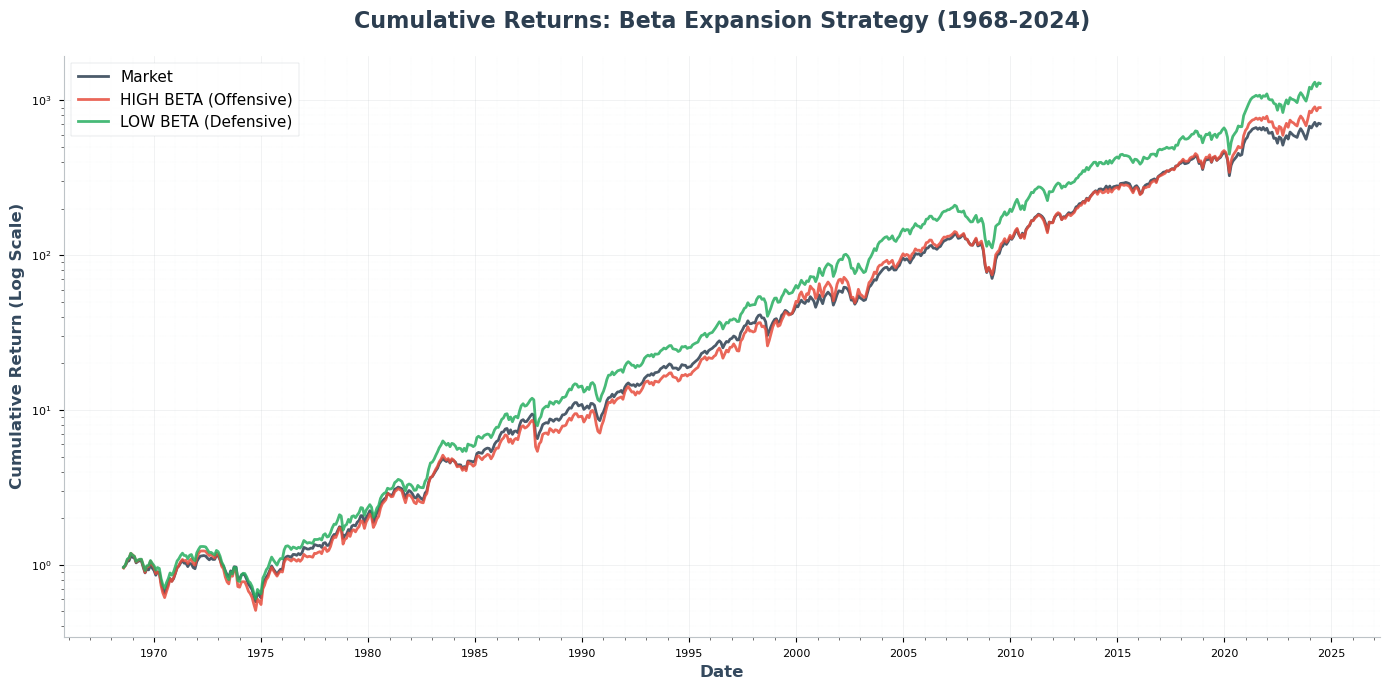


📊 Performance finale (1$ investi) :
   • Market     : $706
   • HIGH BETA  : $899
   • LOW BETA   : $1,288

📈 CAGR (Compound Annual Growth Rate) :
   • Market     : 12.45% per year
   • HIGH BETA  : 12.94% per year
   • LOW BETA   : 13.66% per year

✅ Graphique affiché : Cumulative Returns (Log Scale)
Period start 1968-07-31!


In [30]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 8 : CUMULATIVE RETURNS VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 VISUALISATION : CUMULATIVE RETURNS")
print("="*100)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ════════════════════════════════════════════════════════════════════════════
# 1. COMPUTE CUMULATIVE RETURNS
# ════════════════════════════════════════════════════════════════════════════

cumret = (1 + df_output[['Market', 'HIGH_BETA', 'LOW_BETA']]).cumprod()

# ════════════════════════════════════════════════════════════════════════════
# 2. PLOT (PROFESSIONAL & AUSTERE STYLE)
# ════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

# Plot lines
ax.plot(cumret.index, cumret['Market'], 
        color='#2C3E50', linewidth=2.0, label='Market', alpha=0.85)

ax.plot(cumret.index, cumret['HIGH_BETA'], 
        color='#E74C3C', linewidth=2.0, label='HIGH BETA (Offensive)', alpha=0.85)

ax.plot(cumret.index, cumret['LOW_BETA'], 
        color='#27AE60', linewidth=2.0, label='LOW BETA (Defensive)', alpha=0.85)

# Styling
ax.set_title('Cumulative Returns: Beta Expansion Strategy (1968-2024)', 
             fontsize=16, fontweight='bold', color='#2C3E50', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='600', color='#34495E')
ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12, fontweight='600', color='#34495E')

# Log scale
ax.set_yscale('log')

# Grid
ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='#BDC3C7', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#BDC3C7', alpha=0.2)

# Date formatting
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

# Legend
ax.legend(loc='upper left', frameon=True, shadow=False, 
          framealpha=0.95, edgecolor='#BDC3C7', fontsize=11, fancybox=False)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 3. PERFORMANCE METRICS
# ════════════════════════════════════════════════════════════════════════════

print(f"\n📊 Performance finale (1$ investi) :")
print(f"   • Market     : ${cumret['Market'].iloc[-1]:,.0f}")
print(f"   • HIGH BETA  : ${cumret['HIGH_BETA'].iloc[-1]:,.0f}")
print(f"   • LOW BETA   : ${cumret['LOW_BETA'].iloc[-1]:,.0f}")

n_years = (df_output.index[-1] - df_output.index[0]).days / 365.25

cagr_market = (cumret['Market'].iloc[-1] ** (1/n_years)) - 1
cagr_high = (cumret['HIGH_BETA'].iloc[-1] ** (1/n_years)) - 1
cagr_low = (cumret['LOW_BETA'].iloc[-1] ** (1/n_years)) - 1

print(f"\n📈 CAGR (Compound Annual Growth Rate) :")
print(f"   • Market     : {cagr_market*100:.2f}% per year")
print(f"   • HIGH BETA  : {cagr_high*100:.2f}% per year")
print(f"   • LOW BETA   : {cagr_low*100:.2f}% per year")

print(f"\n✅ Graphique affiché : Cumulative Returns (Log Scale)")
print("="*100)
print('Period start 1968-07-31!')